In [1]:
import os
import numpy as np
from typing import Dict, Tuple, List
import pickle
from utils import utils
from utils.data_utils import load_metadata_and_map

import torch
import cupy as cp
import annoy
import math
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [2]:
METADATA_FILE = "embeddings/id_metadata_arsmagna_test.csv"
TENSOR_DIR = "embeddings/chunked_6s/"

In [3]:
INDEX_FILE = "chunk_6s_index.ann"
KEY_MAP_FILE = "chunk_6s_keymap.pkl"

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
import pandas as pd

metadata_df = pd.read_csv(METADATA_FILE)
print(f"Loaded metadata for {len(metadata_df)} items.")

Loaded metadata for 141139 items.


In [6]:
# load index
idx_size = os.path.getsize(INDEX_FILE)
print(f"Index size: {idx_size} bytes")
print("Loading index...")
index = annoy.AnnoyIndex(1024, "angular")
index.load(INDEX_FILE)

print("Loading key map...")
with open(KEY_MAP_FILE, "rb") as f:
  key_map = pickle.load(f)


Index size: 60038884204 bytes
Loading index...
Loading key map...


In [7]:
# invert key map to track_id and chunk_idx to Annoy integer ID
# Key: TrackID, Value: Dict[ChunkIdx, AnnoyIntegerID]
from collections import defaultdict


inv_key_map: Dict[str, Dict[int, int]] = defaultdict(dict)
for k, v in key_map.items():
  inv_key_map[v[0]][v[1]] = k


In [8]:
def fetch_embeddings(track_id: str) -> List[torch.Tensor]:
  embeddings = []
  for chunk_index, ann_index in inv_key_map[track_id].items():
    embeddings.append(torch.FloatTensor(index.get_item_vector(ann_index)))
  return embeddings

def load_embeddings_from_pt_file(file_path: str) -> List[torch.Tensor]:
  embeddings = torch.load(file_path)
  # convert to list of tensors
  return list(embeddings)


In [19]:
# ColBERT approximation
use_file_embedding = False
# target_embeddings_path = "test/embeddings/【ブルアカ】5周年記念楽曲「Let's Go With…」MV.pt"
target_embeddings_path = "test/embeddings/Vestige.pt"
# target_embeddings_path = "embeddings/chunks_5s_ars/[2016.10.30 [ARS-029] Ariabl'eyeS — 終劇のロマネスク [M3-38]] - 05. Luna, Rena — Romanesque Romancia.allchunks.pt"
target_track_id = '2999dd24-c349-436c-b156-4153ba1b3587'
# get embeddings from index

target_embeddings: List[torch.Tensor] = fetch_embeddings(target_track_id)
population = len(inv_key_map[target_track_id].items())

if use_file_embedding:
  target_embeddings = load_embeddings_from_pt_file(target_embeddings_path)
  population = len(target_embeddings)

In [20]:
vote_map: Dict[str, int] = defaultdict(int)

# compute kNN, and vote for the most frequent neighbors, based on neighbor key
# in theory, to have a high ColBERT maxsim score, there at least should be one chunk in kNN
# otherwise, calculating maxsim across all 7 million embeddings is not feasible
with tqdm(total=len(target_embeddings), desc="Processing target embeddings") as pbar:
  for embedding in target_embeddings:
    neighbors, distances = index.get_nns_by_vector(embedding.numpy(), 100, search_k=10_000, include_distances=True)
    for neighbor, distance in zip(neighbors, distances):
      # key to get track_id and chunk_idx
      ntrack_id, nchunk_idx = key_map[neighbor]
      # normalize votes by neighbor length, as longer neighbors will probabilistically
      # match more index
      neighbor_length = len(inv_key_map[ntrack_id])
      # vote to elect the most frequent track id based on neighbor
      sim_score = 1.0 - (distance**2) / 2.0
      vote_map[ntrack_id] += sim_score
    pbar.update(1)
# order vote
sorted_vote_map = sorted(vote_map.items(), key=lambda x: x[1], reverse=True)


Processing target embeddings: 100%|██████████| 77/77 [00:33<00:00,  2.31it/s]


$$
\text{score}(Q, D) = \sum_{i = 1}^m \max_{j=1}^n \langle q_i, d_j \rangle
$$

In [21]:
# rerank
def calculate_maxsim_score(query_embeddings: torch.Tensor, 
                          doc_embeddings: torch.Tensor) -> float:
  """
  Computes the ColBERT MaxSim score between a Query and a Document.
  
  Args:
      query_embeddings: Tensor of shape (Num_Query_Vectors, Dim)
      doc_embeddings:   Tensor of shape (Num_Doc_Vectors, Dim)
  
  Returns:
      Total relevance score (scalar)
  """
  # 1. Compute Similarity Matrix (Dot Product)
  # Shape: (Num_Query_Vectors, Num_Doc_Vectors)
  # This compares every query vector against every document vector
  sim_matrix = torch.matmul(query_embeddings, doc_embeddings.transpose(0, 1))
  
  # 2. Max-Reduction over Document tokens (dim=1)
  # "For each query vector, what was its best match in the document?"
  # Shape: (Num_Query_Vectors)
  max_scores_per_query_token = torch.max(sim_matrix, dim=1).values
  
  # 3. Summation over Query tokens
  # "Sum up the best matches to get total relevance"
  total_score = torch.sum(max_scores_per_query_token)
  
  return total_score.item()

rank: Dict[str, float] = {}
query_embeddings = torch.stack(target_embeddings).to(device)
# normalize query embeddings
query_embeddings = torch.nn.functional.normalize(query_embeddings, p=2, dim=1)

with tqdm(total=len(sorted_vote_map), desc="Computing ColBERT maxsim score") as pbar:
  for track_id, score in sorted_vote_map:
    # get embeddings
    doc_embeddings = torch.stack(fetch_embeddings(track_id)).to(device)
    # normalize doc embeddings
    doc_embeddings = torch.nn.functional.normalize(doc_embeddings, p=2, dim=1)
    rank[track_id] = calculate_maxsim_score(query_embeddings, doc_embeddings)
    pbar.update(1)


Computing ColBERT maxsim score: 100%|██████████| 1628/1628 [00:05<00:00, 287.18it/s]


In [22]:
# map this to metadata
ranked_metadata = metadata_df[metadata_df['TrackID'].isin(rank.keys())]
ranked_metadata['score'] = ranked_metadata['TrackID'].map(rank)
ranked_metadata = ranked_metadata.sort_values(by='score', ascending=False)
print("Maximum score: ", max(rank.values()), "| Theorical Maximum ", population)
ranked_metadata.head(30)


Maximum score:  77.0 | Theorical Maximum  77


/tmp/ipykernel_1113/2371228434.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ranked_metadata['score'] = ranked_metadata['TrackID'].map(rank)


,AlbumID,AlbumName,TrackID,TrackName,ArtistName,score
88008,9fa81231-eaf9-4df6-8473-a5023aedf6ef,Best Symphonie Album,33d95d1e-2cdf-4016-a066-cc5da6cab334,瑠璃色ソワレ,Melonbooks Records,77.000000
37404,44001323-a9ea-4e57-9474-a866fb74bcc2,Melonbooks Best Sinfonie Album,2999dd24-c349-436c-b156-4153ba1b3587,瑠璃色ソワレ,Melonbooks Records,77.000000
44401,5020e2f6-6c3b-459d-8ea6-ab295d1c69c5,Iconostasis,cefa3f08-14b0-451f-9e5c-f3ca8ad5e6ad,聖なる激情 ～織部まふゆ・山辺燈～,葉月ゆら,76.270111
77684,8d89acaf-a76e-4129-9216-5c2dd7fbf2a5,恋の夢幻,3363dd21-b9d2-4936-90be-1497b20b4f7e,夢路現ニ想イ群咲ク -PURPLE END- (Album ver.),アールグレイ,76.258270
67400,7aef7a6d-1dc3-41da-a812-6b5a26af81d3,PAINS／座標,c9832705-cede-46e4-b324-45808ce8f28d,ツナガル セツナ-Another World-,イノライ,76.256805
25996,306813d4-54fa-46be-8988-074933a7f71b,Daydream Blossom,b9f4dbf6-6dad-4860-8fe4-bbfa4767d2fa,HERMIT PURPLE,羽っ鳥もさく共和国,76.256134
31948,3b158fbe-a24a-482e-b56a-e8bcba00b11f,デジウィBEST 2022,c21f5869-e47e-4ab2-b59a-fecdbb67c41b,Love song with heart,DiGiTAL WiNG,76.250351
81619,94575d03-da90-49d3-a9ca-56b7d56d9768,ケダモノの唄,c4f27acd-2a70-4a1a-97bb-ce6785206df6,ケダモノの唄,イノライ,76.248962
48277,5777a2a7-5660-4e96-8548-c08c6e93b4db,悦楽バージン,9ad366e3-22d5-43ba-8140-36afb31b0719,メイドノミヤゲ／メイドと血の懐中時計 [東方紅魔郷],東方事変,76.240280
48038,57060999-1993-4fab-a23e-3dc5e8485a68,月夜のレインドロップ,a96f9a0c-2639-49f7-8d42-289973f6a631,影踏み鬼のあしあと,Sister's Spread-i,76.235710


Visualizing match: Query vs. 聖なる激情　～織部まふゆ・山辺燈～ (cefa3f08-14b0-451f-9e5c-f3ca8ad5e6ad)


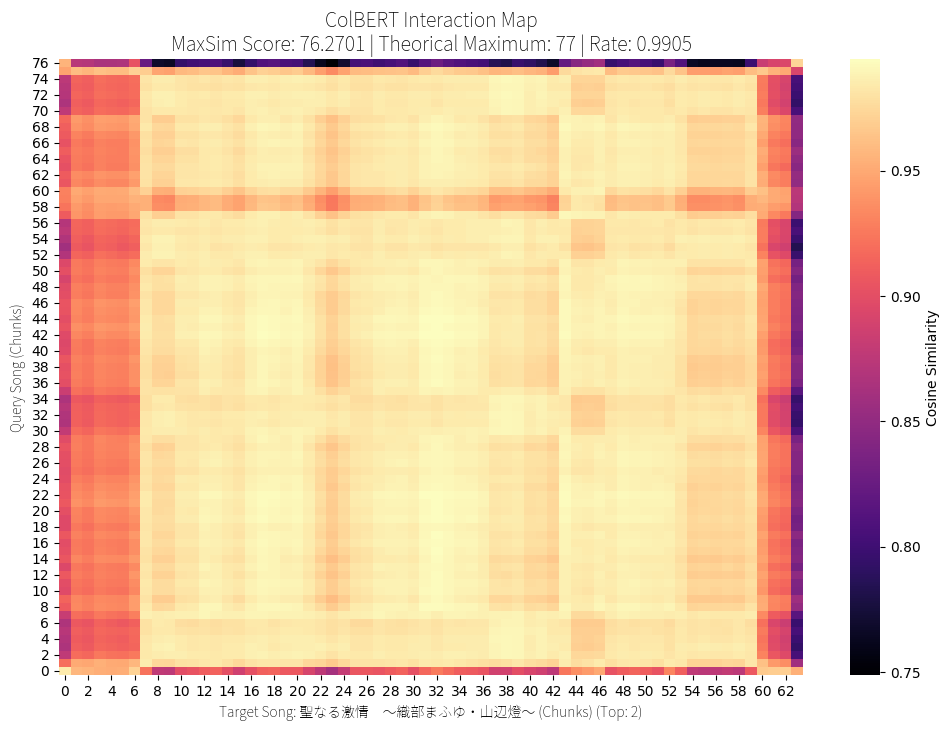

In [24]:
font_path = "fonts/NotoSansJP-VariableFont_wght.ttf"
custom_font = fm.FontProperties(fname=font_path)

TOP_RESULT_IDX = 2

# 1. Get the Top Result Info
top_result_row = ranked_metadata.iloc[TOP_RESULT_IDX]
top_track_id = top_result_row['TrackID']
top_track_title = top_result_row['TrackName']
print(f"Visualizing match: Query vs. {top_track_title} ({top_track_id})")

# 2. Fetch and Normalize Target Embeddings (Re-doing this just for the plot)
top_doc_vecs = fetch_embeddings(top_track_id)
top_doc_embeddings = torch.stack(top_doc_vecs).to(device)
top_doc_embeddings = torch.nn.functional.normalize(top_doc_embeddings, p=2, dim=1)

# 3. Compute Similarity Matrix
# shape: [Num_Query_Chunks, Num_Doc_Chunks]
# We move to CPU and numpy for plotting
sim_matrix = torch.matmul(query_embeddings, top_doc_embeddings.transpose(0, 1)).detach().cpu().numpy()

# 4. Plotting
plt.figure(figsize=(12, 8))

# Use a heatmap with a "magma" or "viridis" colormap to show intensity
# Origin='lower' puts (0,0) at the bottom left (standard for time-time plots)
ax = sns.heatmap(sim_matrix, cmap='magma', cbar_kws={'label': 'Cosine Similarity'})

ax.invert_yaxis() # Ensure time starts from bottom-left
plt.xlabel(f"Target Song: {top_track_title} (Chunks) (Top: {TOP_RESULT_IDX})", fontproperties=custom_font,)
plt.ylabel("Query Song (Chunks)", fontproperties=custom_font)
plt.title(f"ColBERT Interaction Map\nMaxSim Score: {top_result_row['score']:.4f} | Theorical Maximum: {population} | Rate: {top_result_row['score'] / population:.4f}", fontproperties=custom_font, fontsize=14)

plt.show()

# ### Interpret the Heatmap:
# * **Diagonal Lines:** Indicate structural matching (the songs progress similarly).
# * **Horizontal Lines:** A specific motif in the Query matches multiple parts of the Target.
# * **Vertical Lines:** A single moment in the Target matches frequent sounds in the Query.